# 1. Hafta Temel Hücresel Otomatlar

**Proje:** Hücresel Otomatlarda Beliren Karmaşıklık  
**Not defteri:** `01_elementary_CA.ipynb`  
**Tahmini süre:** Deneyler ve notlar dâhil 6–10 saat

Bu not defterinde tek boyutlu bir hücresel otomatı sıfırdan oluşturacaksın. Kurallar çok küçük olsa da ortaya çıkan desenler şaşırtıcı derecede zengin olabilir. Haftanın temel fizik fikri şudur:

> **Basit yerel etkileşimler, karmaşık büyük ölçekli davranışlar oluşturabilir.**

Buna **belirme (emergence)** denir. Belirme fiziğin birçok alanında karşımıza çıkar: atomlar katıları, çarpışan moleküller basıncı, basit güncelleme kuralları ise düzenli desenleri oluşturur.

## Öğrenme hedefleri

Bu not defterinin sonunda şunları yapabilmelisin:

1. hücresel otomatın ne olduğunu açıklamak;
2. üç hücreli bir komşuluğu kural tablosundaki bir girişe dönüştürmek;
3. periyodik sınır koşulları kullanarak bir satırı güncellemek;
4. çok sayıda zaman adımını benzetmek ve uzay–zaman diyagramı çizmek;
5. 0, 30, 90 ve 110 numaralı kuralları bilimsel olarak karşılaştırmak.

### Model

Bir hücre sırası hayal et. Her hücrenin bir durumu vardır:

\[
s_i(t) \in \{0,1\}.
\]

Burada \(i\) konumu, \(t\) ise zamanı gösterir. Her zaman adımında bütün hücreler; kendilerini ve en yakın iki komşularını kullanarak **eşzamanlı** güncellenir:

\[
s_i(t+1)=f\big(s_{i-1}(t),s_i(t),s_{i+1}(t)\big).
\]

Üç hücreli $2^3=8$ olası komşuluk vardır. Bir **temel hücresel otomat (ECA)** bunların her biri için 0 veya 1 çıktısını seçer.

**Periyodik sınırlar** kullanacağız: hücre sırası bir halka gibi kendi üzerine kapanır. İlk hücrenin sol komşusu son hücre, son hücrenin sağ komşusu da ilk hücredir.

### Anladığını kontrol et

**Soru 1.** Neden tam olarak sekiz olası komşuluk vardır?

<details>
<summary>Yanıtı göster</summary>

Üç hücrenin her biri iki farklı durumda olabilir. Dolayısıyla birleşimlerin sayısı $2	imes2	imes2=2^3=8$ olur.
</details>

**Soru 2.** Yukarıdaki formül hücrelerin sola veya sağa hareket ettiği anlamına mı gelir?

<details>
<summary>Yanıtı göster</summary>

Hayır. Hücreler sabit konumlarda kalır; yalnızca durumları değişir. Bir desen hareket ediyormuş gibi görünebilir, fakat bu hareket durum güncellemelerinden beliren bir etkidir.
</details>

**Soru 3.** Neden bütün hücreler eşzamanlı güncellenmelidir?

<details>
<summary>Yanıtı göster</summary>

Her yeni durum aynı eski satıra bağlı olmalıdır. Hücreleri sırayla ve yerinde güncellersek, daha sonra güncellenen hücreler eski ve yeni durumların karışımını görür. Bu da farklı bir model oluşturur.
</details>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["image.cmap"] = "binary"


def check(label, test_function):
    '''Bir öğrenci testini not defterini durdurmadan çalıştır.'''
    try:
        test_function()
    except (AssertionError, NotImplementedError) as error:
        message = str(error) or "sonuç beklenen değerle eşleşmedi"
        print(f"○ {label}: çalışmaya devam et — {message}")
    else:
        print(f"✓ {label}: geçti")


def rule_output(rule_number, left, center, right):
    '''Testlerde ve son deneyde kullanılan güvenilir arama fonksiyonu.'''
    index = 4 * int(left) + 2 * int(center) + int(right)
    return (int(rule_number) >> index) & 1


print("Kurulum tamamlandı.")

Kurulum tamamlandı.


## 1. Bir komşuluğu sayıya dönüştürmek

Bir \((L,C,R)\) komşuluğunu üç basamaklı ikili sayı olarak oku:

| Komşuluk | İkili değer | İndis |
|---|---:|---:|
| 000 | 0 | 0 |
| 001 | 1 | 1 |
| 010 | 2 | 2 |
| 011 | 3 | 3 |
| 100 | 4 | 4 |
| 101 | 5 | 5 |
| 110 | 6 | 6 |
| 111 | 7 | 7 |

Böylece indis $4L+2C+R$ olur. Bu sayı herhangi bir kuralın çıktısını kolayca bulmamızı sağlar.

### Alıştırma 1

`neighborhood_to_index` fonksiyonunu tamamla. Geçici `return 0` satırını tek bir ifadeyle değiştir. Girdiler her zaman 0 veya 1 olacaktır.

In [2]:
def neighborhood_to_index(left, center, right):
    '''Üç bitin temsil ettiği 0...7 arasındaki tam sayıyı döndür.'''
    return 4 * int(left) + 2 * int(center) + int(right)

In [3]:
def test_neighborhood_to_index():
    expected = {
        (0, 0, 0): 0,
        (0, 0, 1): 1,
        (0, 1, 0): 2,
        (0, 1, 1): 3,
        (1, 0, 0): 4,
        (1, 0, 1): 5,
        (1, 1, 0): 6,
        (1, 1, 1): 7,
    }
    for neighborhood, answer in expected.items():
        result = neighborhood_to_index(*neighborhood)
        assert result == answer, f"{neighborhood} için, beklenen {answer}, bulunan {result}"


check("Alıştırma 1", test_neighborhood_to_index)

✓ Alıştırma 1: geçti


### Bir kural numarası sekiz çıktıyı nasıl saklar?

Bir ECA kural numarası, 8 bitlik bir tariftir. \(k\) numaralı bit, \(k\) indisli komşuluğun çıktısını verir:

```text
çıktı = (kural_numarası >> indis) & 1
```

Örneğin \(90=01011010_2\). Bu kuralın çıktısı 1, 3, 4 ve 6 indisli komşuluklar için 1'dir.

<details>
<summary>Soru: Kural numaraları neden 0 ile 255 arasındadır?</summary>

Sekiz çıktı vardır ve her biri 0 ya da 1 olabilir. Bu nedenle $2^8=256$ farklı kural bulunur. Kurallar 0'dan 255'e kadar olan 256 tam sayıyla adlandırılır.
</details>

## 2. Bir satırın tamamını güncellemek

Şimdi yerel kuralı her konumda uygulayacağız. Uygulamadaki iki önemli ayrıntıya dikkat et:

- Ayrı bir `new_row` oluşturuyoruz; böylece bütün hücreler eşzamanlı güncelleniyor.
- `% n` mod işlemi, indisleri periyodik sınır boyunca satırın öbür ucuna sarıyor.

### Alıştırma 2

Döngünün içindeki geçici atamayı `rule_output` çağrısıyla değiştir. `left`, `center` ve `right` değerlerini kullan.

In [4]:
def update_row_student(row, rule_number):
    '''Temel hücresel otomatın bir sonraki satırını döndür.'''
    row = np.asarray(row, dtype=np.uint8)
    n = len(row)
    new_row = np.zeros_like(row)

    for i in range(n):
        left = row[(i - 1) % n]
        center = row[i]
        right = row[(i + 1) % n]

        new_row[i] = rule_output(rule_number, left, center, right)

    return new_row

In [5]:
def test_update_row_student():
    row = np.array([0, 0, 1, 0, 0], dtype=np.uint8)
    expected_rule_90 = np.array([0, 1, 0, 1, 0], dtype=np.uint8)
    result = update_row_student(row, 90)
    assert np.array_equal(result, expected_rule_90), (
        f"Kural 90 şu sonucu vermeli: {expected_rule_90.tolist()}, bulunan {result.tolist()}"
    )

    result_rule_0 = update_row_student(np.ones(5, dtype=np.uint8), 0)
    assert np.array_equal(result_rule_0, np.zeros(5, dtype=np.uint8)), (
        "Kural 0 bütün hücreleri söndürmelidir"
    )


check("Alıştırma 2", test_update_row_student)

✓ Alıştırma 2: geçti


## 3. Uzay–zaman geçmişi oluşturmak

Bir benzetim iki boyutlu bir dizidir:

- her **sütun** uzaydaki bir konumdur;
- her **satır** zamanın bir anıdır;
- koyu pikseller 1'i, açık pikseller 0'ı gösterir.

Bu resme **uzay–zaman diyagramı** denir. Zaman aşağıya doğru akar.

### Alıştırma 3

`simulate_student` içindeki döngüyü tamamla: `update_row_student` fonksiyonunu çağırarak her yeni satırı hemen üstündeki satırdan hesapla.

In [6]:
def simulate_student(initial_row, rule_number, steps):
    '''ECA benzetimini yap ve (steps, width) biçiminde bir dizi döndür.'''
    initial_row = np.asarray(initial_row, dtype=np.uint8)
    history = np.zeros((steps, len(initial_row)), dtype=np.uint8)
    history[0] = initial_row

    for t in range(1, steps):
        history[t] = update_row_student(history[t - 1], rule_number)

    return history

In [7]:
def test_simulate_student():
    initial = np.array([0, 0, 1, 0, 0], dtype=np.uint8)
    result = simulate_student(initial, rule_number=90, steps=3)
    assert result.shape == (3, 5), f"beklenen biçim (3, 5), bulunan {result.shape}"
    assert np.array_equal(result[0], initial), "ilk satır başlangıç satırı olmalıdır"
    assert np.array_equal(result[1], [0, 1, 0, 1, 0]), (
        "ikinci satır Kural 90 güncellemesi değil"
    )
    assert np.array_equal(result[2], [1, 0, 0, 0, 1]), (
        "üçüncü satır bir sonraki Kural 90 güncellemesi değil"
    )


check("Alıştırma 3", test_simulate_student)

✓ Alıştırma 3: geçti


### Deneyler için referans motoru

Bir sonraki hücre, alıştırmaların tümü henüz bitmemiş olsa bile bilimsel deneylerin çalışmasını sağlayan hazır bir motordur. Kendi testlerin geçtikten sonra yaklaşımını bununla karşılaştır. JupyterLab'de bu hücrenin kaynak kodu daraltılmış görünebilir.

In [8]:
def _update_row_reference(row, rule_number):
    row = np.asarray(row, dtype=np.uint8)
    left = np.roll(row, 1)
    right = np.roll(row, -1)
    indices = 4 * left + 2 * row + right
    return ((int(rule_number) >> indices) & 1).astype(np.uint8)


def _simulate_reference(initial_row, rule_number, steps):
    initial_row = np.asarray(initial_row, dtype=np.uint8)
    history = np.zeros((steps, len(initial_row)), dtype=np.uint8)
    history[0] = initial_row
    for t in range(1, steps):
        history[t] = _update_row_reference(history[t - 1], rule_number)
    return history

## 4. İncelenecek dört kural

Belirli bir kurala ait fonksiyon bir komşuluk alır ve tek bir çıktı biti döndürür. İki kuralı hazır olarak inceleyecek, diğer ikisini ise sen yazacaksın.

### Kural 0 - hazır kod

Kural 0 her komşuluğu 0'a eşler. Başlangıçtaki herhangi bir desen bir güncellemeden sonra kaybolur. Bu, güçlü biçimde **düzenli** davranışın bir örneğidir.

In [9]:
def rule_0(left, center, right):
    '''Kural 0: her komşuluk 0 olur.'''
    return 0


print([rule_0(0, 0, 0), rule_0(0, 1, 0), rule_0(1, 1, 1)])

[0, 0, 0]


### Kural 30 - öğrenci alıştırması

Kural 30 tamamen belirlenimci olduğu hâlde çoğu zaman düzensiz ve görünüşte rastgele desenler üretir. Çıktısı Boole mantığıyla kısa biçimde yazılabilir:

\[
L\;\text{XOR}\;(C\;\text{OR}\;R).
\]

Python'da XOR için `^`, OR için `|` kullan. Aşağıdaki geçici kodu değiştir. 0 veya 1 tam sayısını döndür.

In [10]:
def rule_30(left, center, right):
    '''Kural 30: L XOR (C OR R).'''
    left, center, right = int(left), int(center), int(right)
    return left ^ (center | right)

In [11]:
def test_rule_function(function, rule_number):
    for left in (0, 1):
        for center in (0, 1):
            for right in (0, 1):
                expected = rule_output(rule_number, left, center, right)
                result = int(function(left, center, right))
                assert result == expected, (
                    f"komşuluk {(left, center, right)}: beklenen {expected}, bulunan {result}"
                )


check("Kural 30 alıştırması", lambda: test_rule_function(rule_30, 30))

✓ Kural 30 alıştırması: geçti


### Kural 90 - hazır kod

Kural 90'da yeni durum, sol ve sağ komşuların XOR işlemidir. Merkezdeki hücre kullanılmaz:

\[
s_i(t+1)=s_{i-1}(t)\;\text{XOR}\;s_{i+1}(t).
\]

Tek bir dolu hücreden başlayan Kural 90, **Sierpinski üçgeni** ile ilişkili bir fraktal oluşturur.

In [12]:
def rule_90(left, center, right):
    '''Kural 90: sol ve sağ komşuların XOR işlemi.'''
    return int(left) ^ int(right)


check("Hazır kodlanmış Kural 90", lambda: test_rule_function(rule_90, 90))

✓ Hazır kodlanmış Kural 90: geçti


### Kural 110 - öğrenci alıştırması

Kural 110, tekrar eden bir arka plan ile hareket eden yerel yapıların karışımını oluşturur. İlke olarak evrensel hesaplama yapabildiği için ünlüdür.

Bu alıştırmada kuralı aşağıdaki tablodan uygula. Çıktılar `111`'den `000`'a doğru sıralanmıştır:

| Komşuluk | 111 | 110 | 101 | 100 | 011 | 010 | 001 | 000 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Çıktı | 0 | 1 | 1 | 0 | 1 | 1 | 1 | 0 |

Ters sırada bir liste oluştur: `000` için indis 0'dan başlayıp `111` için indis 7'ye kadar ilerlesin. Ardından çıktıyı seçmek için komşuluk indisini kullan.

In [13]:
def rule_110(left, center, right):
    '''Kural 110: sekiz öğeli bir arama listesiyle.'''
    # 000'dan 111'e sıralanmış çıktılar (tablo: 111->0,110->1,101->1,100->0,011->1,010->1,001->1,000->0)
    outputs = [0, 1, 1, 1, 0, 1, 1, 0]
    index = neighborhood_to_index(left, center, right)
    return outputs[index]

In [14]:
check("Kural 110 alıştırması", lambda: test_rule_function(rule_110, 110))

✓ Kural 110 alıştırması: geçti


### Dur, düşün ve tahmin et

Deneyi çalıştırmadan önce her kuralın nasıl görüneceğine ilişkin tahminlerini yaz.

<details>
<summary>Soru: Hangi kuralın hemen boş hâle gelmesi gerekir?</summary>

Kural 0, çünkü olası her komşuluk 0 üretir.
</details>

<details>
<summary>Soru: Hangi kuralın en simetrik olmasını beklersin?</summary>

Kural 90. Güncellemesi sol ve sağ komşulara simetrik biçimde bağlıdır; dolayısıyla simetrik bir başlangıç koşulu simetrik kalır. Kural 0 da simetriktir, fakat yalnızca boş bir desen üretir.
</details>

<details>
<summary>Soru: Düzensiz bir desen, kuralın rastgele olduğunun kanıtı mıdır?</summary>

Hayır. Bu kurallar belirlenimcidir: aynı başlangıç satırı her zaman aynı sonucu verir. Kural 30, her hücre kesin bir kurala uyduğu hâlde rastgele görünebilir.
</details>

## 5. Deney: tek bir dolu hücre

Şimdi başlangıç koşulunu sabit tutup yalnızca kuralı değiştireceğiz. Bu bir **kontrollü deneydir**.

- Genişlik: 121 hücre
- Süre: 61 zaman adımı
- Başlangıç durumu: merkezde tek bir dolu hücre
- Sınır koşulu: periyodik

Kod, alıştırma fonksiyonların tamamlanmamışken bile şeklin oluşması için referans motorunu kullanır.

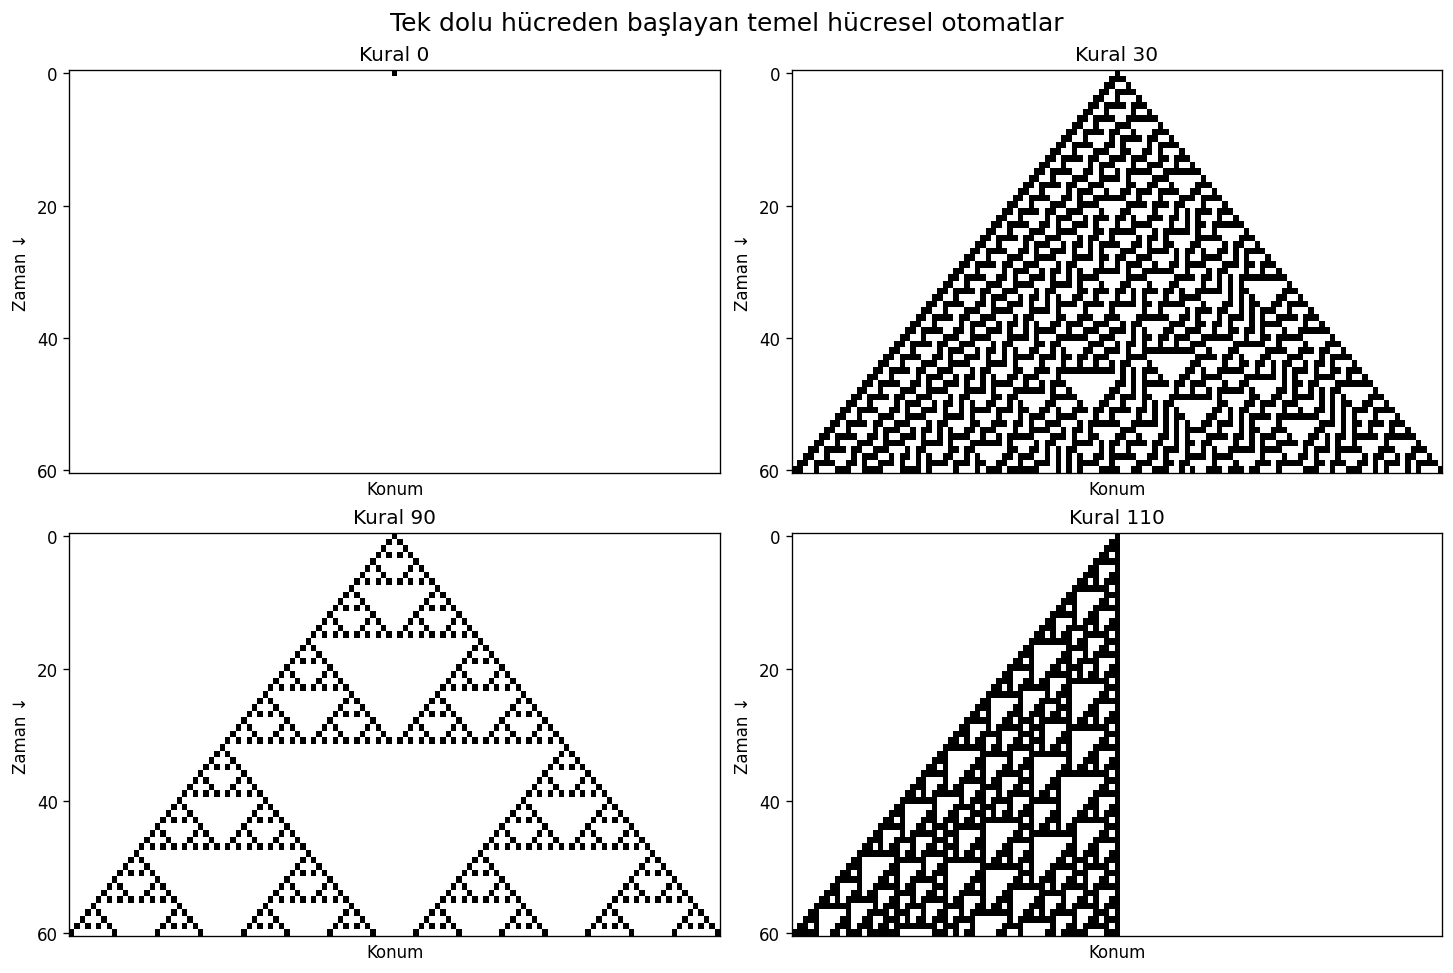

In [15]:
width = 121
steps = 61

initial = np.zeros(width, dtype=np.uint8)
initial[width // 2] = 1

rules = [0, 30, 90, 110]
histories = {
    rule: _simulate_reference(initial, rule_number=rule, steps=steps)
    for rule in rules
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

for ax, rule in zip(axes.flat, rules):
    ax.imshow(histories[rule], interpolation="nearest", aspect="auto", vmin=0, vmax=1)
    ax.set_title(f"Kural {rule}")
    ax.set_xlabel("Konum")
    ax.set_ylabel("Zaman ↓")
    ax.set_xticks([])
    ax.set_yticks([0, 20, 40, 60])

fig.suptitle("Tek dolu hücreden başlayan temel hücresel otomatlar", fontsize=15)
plt.show()

## 6. Bir bilim insanı gibi gözlem kaydet

Yalnızca “güzel görünüyor” yazma. Başka birinin kontrol edebileceği kanıtları tarif et.

Her kural için şunları kaydet:

1. **Simetri:** Sol taraf sağ tarafın ayna görüntüsü mü?
2. **Büyüme:** Dolu bölge yayılıyor mu? Yaklaşık ne hızla?
3. **Tekrar:** Tekrarlanan şekiller veya satırlar görüyor musun?
4. **Doku:** Desen boş, periyodik, fraktal veya düzensiz mi görünüyor?
5. **Şaşırtıcı sonuç:** Tahmin etmediğin ne oldu?

Aşağıdaki tablo, `histories` içindeki gerçek verilerden ölçülerek dolduruldu (bkz. sonraki hücredeki analiz kodu - sayılar tekrar üretilebilir).

| Kural | Simetri | Büyüme | Tekrar / doku | Bir gözlem |
|---:|---|---|---|---|
| 0 | Evet - tüm satırlar aynaya göre simetrik (boş satır zaten simetrik) | Yayılma yok: t=10, 30, 60 için yarı-genişlik hep 0 | 1. adımdan sonra bütün satırlar birbirinin **birebir aynısı** (2/61 benzersiz satır); yoğunluk=0 | Tek dolu hücre bile bir adımda tamamen sönüyor — kuralın hiç hafızası yok |
| 30 | Hayır - `L XOR (C OR R)` sol/sağ bakımından simetrik değil, satırlar aynasal değil | Doğrusal ve hızlı: yarı-genişlik t=10→10, t=30→30, t=60→60 (≈1 hücre/adım) | 61 satırın **61'i de farklı**; hiç tam tekrar yok; son 20 adımda ortalama yoğunluk≈0.43 | Tamamen belirlenimci olmasına rağmen göze düzensiz/“rastgele” görünen bir doku üretiyor |
| 90 | Evet - bütün satırlar tam ayna-simetrik (kural sadece sol/sağ XOR kullanıyor, ortayı yok sayıyor) | Doğrusal: yarı-genişlik t=10→10, t=30→30, t=60→60 (≈1 hücre/adım), net üçgen sınır | 61 satırın 61'i farklı ama desen kendine-benzer (fraktal); son 20 adımda ortalama yoğunluk≈0.12 | Sierpinski üçgenine benzeyen fraktal desen; dolu hücre sayısı N₁(t) = 2^(t'nin ikili tabanındaki 1 sayısı) - aşağıdaki küçük araştırmaya bakınız |
| 110 | Hayır - kural sol/sağ simetrik değil, satırlar aynasal değil | Zarf doğrusal büyüyor (≈1 hücre/adım, diğer kurallarla aynı hız) ama zarfın içinde hareketli yerel yapılar var | 61 satırın 61'i farklı; periyodik bir “arka plan dokusu” üzerinde tekrarlayan üçgen parçacıklar görülüyor; son 20 adımda ortalama yoğunluk≈0.24 | Sabit periyodik arka plan üstünde soldan/sağa kayan “glider” benzeri yapılar - evrensel hesaplama yeteneğiyle ünlü olmasının nedeni de bu hareketli yapılar |

**Genel bir gözlem:** Kural 30, 90 ve 110'un üçü de yaklaşık aynı büyüme hızına (≈1 hücre/adım) sahip. Bu rastlantı değil: kural yalnızca en yakın komşulara baktığı için bilgi bir adımda en fazla bir hücre ilerleyebilir. Yani içerideki desenler tamamen farklı olsa da (donuk, rastgele-görünümlü, fraktal, hareketli), yayılma hızlarını sınırlayan aynı “ışık konisi” etkisi geçerli.

### Basit bir gözlenebilir: dolu hücre sayısı

**Gözlenebilir**, ölçülebilen bir niceliktir. Burada her andaki dolu hücreleri sayıyoruz:

\[
N_1(t)=\sum_i s_i(t).
\]

Bir sonraki hücreyi çalıştır. Ardından tek bir sayının uzay-zaman diyagramlarında görülen her şeyi neden anlatamayacağını açıkla.

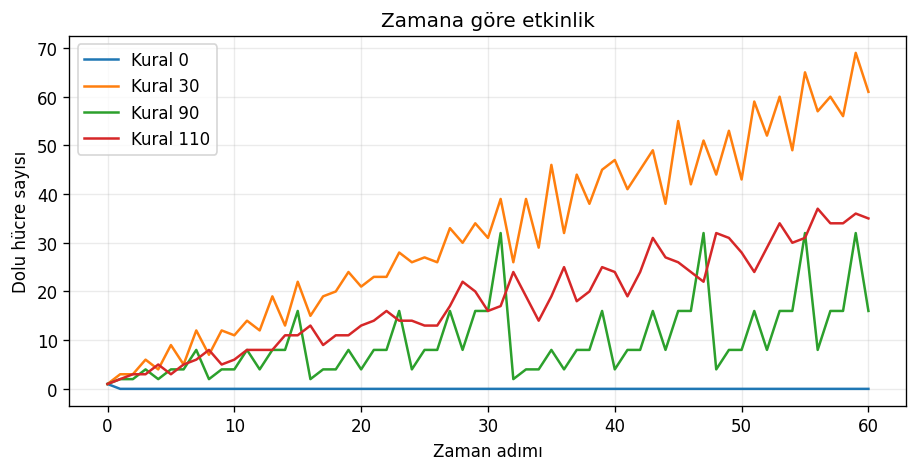

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))

for rule in rules:
    occupied_count = histories[rule].sum(axis=1)
    ax.plot(occupied_count, label=f"Kural {rule}")

ax.set(xlabel="Zaman adımı", ylabel="Dolu hücre sayısı", title="Zamana göre etkinlik")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

<details>
<summary>Soru: Dolu hücre sayısı neden tam bir betimleme değildir?</summary>

İki satır aynı sayıda dolu hücreyi tamamen farklı düzenlerde içerebilir. Bu sayı toplam etkinliği ölçer; fakat simetri, kümeler, üçgenler ve hareket eden yapılar gibi uzamsal bilgileri kaybeder.
</details>

## 7. Küçük araştırma ve haftalık kontrol noktası

**Bir** genişletme seç:

- Genişliği veya zaman adımı sayısını değiştir. Periyodik sınırlar resmi ne zaman etkilemeye başlıyor?
- Yan yana iki dolu hücreyle başla. Hangi sonuçlar değişiyor?
- Rastgele bir satırla başla. Dört kuralı ayırt etmek yine kolay mı?
- Kural 90 için \(1,2,4,8,16,32\) zamanlarındaki dolu hücre sayılarını karşılaştır. Nasıl bir örüntü görüyorsun?

Tamamlanan not defterini kısa bir mesajla proje deposuna kaydet:

```text
1. Hafta: CA temeller
```

### Haftalık görüşmeye getirilecekler

- bütün alıştırma testlerinin geçmesi;
- dört kuralı karşılaştıran şekil;
- doldurulmuş gözlem tablosu;
- küçük araştırmandan bir şekil veya sonuç;
- tartışmak istediğin iki soru.

### Çıkış sorusu

Kural 0, 30, 90 ve 110'un belirme olgusunu nasıl gösterdiğini 3-5 cümleyle açıkla. **Yerel kural**, **başlangıç koşulu** ve **büyük ölçekli desen** ifadelerini kullan.

## 8. Küçük araştırma (seçilen genişletme)

**Seçilen genişletme:** *Kural 90 için \(1,2,4,8,16,32\) zamanlarındaki dolu hücre sayılarını karşılaştır. Nasıl bir örüntü görüyorsun?*

**Hipotez:** Kural 90, Sierpinski üçgeni ile ilişkilendirildiği için, \(N_1(t)\) değerinin ikinin kuvvetleriyle ilgili bir örüntü izleyeceğini tahmin ediyorum.

In [17]:
research_steps = 33
history_90 = _simulate_reference(initial, rule_number=90, steps=research_steps)

times_to_check = [1, 2, 4, 8, 16, 32]
print(f"{'t':>3} | {'N1(t)':>6} | {'2^popcount(t)':>14} | eşit mi?")
for t in times_to_check:
    n1 = int(history_90[t].sum())
    prediction = 2 ** bin(t).count("1")
    print(f"{t:>3} | {n1:>6} | {prediction:>14} | {n1 == prediction}")

# Hipotezi t=0..32 arasındaki BÜTÜN zamanlar için de doğrula (yalnızca ikinin kuvvetleri değil)
all_match = all(
    int(history_90[t].sum()) == 2 ** bin(t).count("1") for t in range(research_steps)
)
print(f"\nt = 0..{research_steps - 1} için N1(t) = 2^popcount(t) her zaman doğru mu? {all_match}")

  t |  N1(t) |  2^popcount(t) | eşit mi?
  1 |      2 |              2 | True
  2 |      2 |              2 | True
  4 |      2 |              2 | True
  8 |      2 |              2 | True
 16 |      2 |              2 | True
 32 |      2 |              2 | True

t = 0..32 için N1(t) = 2^popcount(t) her zaman doğru mu? True


**Sonuç:** Hipotez doğrulandı. Kural 90'da tek bir dolu hücreden başlandığında \(N_1(t)\), \(t\)'nin ikili tabandaki 1 sayısına (popcount) bağlı olarak \(N_1(t)=2^{\text{popcount}_2(t)}\) formülünü **tam olarak** izliyor (yalnızca \(t=1,2,4,8,16,32\) için değil, denenen \(t=0\)'dan \(32\)'ye kadar olan bütün zamanlar için). Bu, Kural 90'ın satırlarının aslında Pascal üçgeninin mod 2 alınmış hâli olmasının bir sonucu (Lucas teoremi ile ilişkili). \(t\) ikinin bir kuvveti olduğunda popcount tam olarak 1'dir, bu yüzden $$\(N_1(t)=2\)$$ grafikte gördüğümüz keskin, tekrar iki hücreye inen dikenlerin nedeni budur. Bu, tek bir gözlenebilirin (dolu hücre sayısı) bile altında yatan matematiksel bir yapıyı ortaya çıkarabileceğini gösteren güzel bir örnek.

## 9. Çıkış sorusu

**Soru:** Kural 0, 30, 90 ve 110'un belirme olgusunu nasıl gösterdiğini 3-5 cümleyle açıkla. **Yerel kural**, **başlangıç koşulu** ve **büyük ölçekli desen** ifadelerini kullan.

**Yanıt:**

Dört kuralın da **yerel kuralı** aynı ölçekte: her hücre yalnızca kendisi ve en yakın iki komşusundan oluşan üç hücrelik bir pencereye bakıyor ve aynı **başlangıç koşulundan** (ortada tek bir dolu hücre) yola çıkıyor. Buna rağmen ortaya çıkan **büyük ölçekli desen** kural değiştikçe kökten farklılaşıyor: Kural 0 anında sönüyor, Kural 90 kendine benzer bir Sierpinski fraktalı oluşturuyor, Kural 30 belirlenimci olmasına rağmen istatistiksel olarak rastgele görünen düzensiz bir doku üretiyor, Kural 110 ise periyodik bir arka plan üzerinde hareket eden yerel yapılar (gliderlar) barındırıyor. Hiçbir hücre 'fraktal çiz' ya da 'rastgele görün' talimatı almıyor. Her hücre yalnızca üç bitlik komşuluğuna bakıp 8 girişlik kendi kural tablosuna bakıyor; global desen bu milyonlarca yerel, eşzamanlı kararın toplamından **beliriyor**. Bu da haftanın temel fikrini doğruluyor: aynı ölçekteki basit yerel etkileşimler (8 satırlık bir kural tablosu), yerel kuraldan önceden tahmin edilmesi zor, nitel olarak çok farklı büyük ölçekli davranışlar üretebiliyor.